# 2. Simple CNN Models

**Goal:** train simple CNNs of increasing depth and compare them.

**Block order (standard):** `Conv2D → BatchNorm → ReLU → MaxPooling → Dropout`
**Dense head:** `Flatten → Dense → BatchNorm → ReLU → Dropout → Dense(73, softmax)`

| Choice | Why |
|---|---|
| **MaxPooling** | Images are 224x224, so feature maps (and the Dense layer after `Flatten`) get very large. Each pooling halves height and width, cutting parameters and compute. |
| **BatchNorm** | Normalises activations, so training is faster and more stable. Also used after the Dense layer: without it, the very large `Flatten` input pushed all Dense ReLUs to zero ("dead") and the models stayed at chance accuracy. |
| **ReLU** | Simple and cheap; does not saturate for positive values, so it avoids vanishing gradients. |
| **Dropout** | Randomly drops units during training, so the network learns more robust features and overfits less. |
| **Adam** | Adaptive learning rate; converges fast with default settings. *Options:* `SGD(momentum=0.9)` (often slightly better generalisation, but slower to train) or `RMSprop`. Pass via `optimizer=`. |
| **Loss** | Sparse categorical cross-entropy (73 classes, integer labels). |
| **Early stopping** | Stops when validation accuracy stops improving (patience 5) and restores the best weights. |
| **Seed** | `set_random_seed(42)` before each model, so results are reproducible. |

In [1]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers

SEED = 42
EPOCHS = 30
BATCH = 32
PATIENCE = 5
keras.utils.set_random_seed(SEED)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2})
TRAIN_C, VAL_C, TEST_C = '#2a78d6', '#eb6834', '#1baf7a'

In [2]:
data = np.load('data/dataset.npz')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
CLASSES = data['classes']
NUM_CLASSES = len(CLASSES)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Classes:', NUM_CLASSES)

Train: (5120, 224, 224, 3) | Val: (1097, 224, 224, 3) | Classes: 73


## 2.1 Generic Model Function

In [3]:
def augmentation():
    # Same pipeline as notebook 1. Active only during training (model.fit).
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomPerspective(factor=0.5, scale=0.2),   # warp
        layers.RandomGaussianBlur(factor=0.5, sigma=1.0),  # blur
    ], name='augmentation')


def build_simple_cnn(name, filters, dense_units=128, dropout=0.25, optimizer='adam'):
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential(name=name)
    model.add(keras.Input(shape=(224, 224, 3)))
    model.add(augmentation())
    model.add(layers.Rescaling(1. / 255))
    for f in filters:                      # one block per filter size
        model.add(layers.Conv2D(f, 3, padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(dropout))
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units))   # same order as conv blocks
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
results, histories = {}, {}

def count_layers(model):
    return sum(count_layers(l) if isinstance(l, keras.Model) else 1 for l in model.layers)

def train(model, architecture):
    early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                                               restore_best_weights=True)
    start = time.time()
    h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS,
                  batch_size=BATCH, shuffle=True, callbacks=[early_stop], verbose=2)
    train_time = time.time() - start

    model.save(f'models/{model.name}.keras')
    with open(f'results/history_{model.name}.json', 'w') as f:
        json.dump(h.history, f)

    best = int(np.argmax(h.history['val_accuracy']))
    histories[model.name] = h.history
    results[model.name] = {
        'Model': model.name, 'Architecture': architecture,
        'Layers': count_layers(model), 'Params': model.count_params(),
        'Trainable Params': int(sum(np.prod(w.shape) for w in model.trainable_weights)),
        'Epochs Run': len(h.history['accuracy']), 'Best Epoch': best + 1,
        'Train Acc': round(h.history['accuracy'][best], 4),
        'Val Acc': round(h.history['val_accuracy'][best], 4),
        'Train Time (s)': round(train_time),
    }
    print(results[model.name])

## 2.2 CNN_1 — 2 blocks [32, 64]
`Conv(32) → Conv(64) → Flatten → Dense(128) → Dense(73)`

Shallow baseline. Only 2 poolings leave a 56x56x64 map, so the Dense layer is very large.

In [5]:
cnn_1 = build_simple_cnn('CNN_1', [32, 64])
cnn_1.summary()
train(cnn_1, 'Conv [32, 64]')

Model: "CNN_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 73)             │         9,417 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,719,945 (98.11 MB)

 Trainable params: 25,719,497 (98.11 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
160/160 - 71s - 444ms/step - accuracy: 0.0740 - loss: 4.1004 - val_accuracy: 0.0128 - val_loss: 4.6026
Epoch 2/30
160/160 - 69s - 433ms/step - accuracy: 0.1867 - loss: 3.4767 - val_accuracy: 0.0611 - val_loss: 4.1729
Epoch 3/30
160/160 - 70s - 436ms/step - accuracy: 0.2564 - loss: 3.1042 - val_accuracy: 0.2242 - val_loss: 3.2423
Epoch 4/30
160/160 - 69s - 434ms/step - accuracy: 0.3033 - loss: 2.8654 - val_accuracy: 0.3127 - val_loss: 2.8327
Epoch 5/30
160/160 - 69s - 432ms/step - accuracy: 0.3363 - loss: 2.6798 - val_accuracy: 0.4057 - val_loss: 2.5290
Epoch 6/30
160/160 - 69s - 434ms/step - accuracy: 0.3680 - loss: 2.5242 - val_accuracy: 0.4075 - val_loss: 2.4842
Epoch 7/30
160/160 - 70s - 435ms/step - accuracy: 0.3977 - loss: 2.3720 - val_accuracy: 0.4102 - val_loss: 2.4255
Epoch 8/30
160/160 - 69s - 431ms/step - accuracy: 0.4338 - loss: 2.2574 - val_accuracy: 0.4330 - val_loss: 2.2858
Epoch 9/30
160/160 - 69s - 432ms/step - accuracy: 0.4369 - loss: 2.1820 - val_accuracy: 

## 2.3 CNN_2 — 3 blocks [32, 64, 64]
`Conv(32) → Conv(64) → Conv(64) → Flatten → Dense(128) → Dense(73)`

In [6]:
cnn_2 = build_simple_cnn('CNN_2', [32, 64, 64])
cnn_2.summary()
train(cnn_2, 'Conv [32, 64, 64]')

Model: "CNN_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 73)             │         9,41

 Total params: 6,489,545 (24.76 MB)

 Trainable params: 6,488,969 (24.75 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/30
160/160 - 84s - 522ms/step - accuracy: 0.0848 - loss: 4.1071 - val_accuracy: 0.0137 - val_loss: 4.6674
Epoch 2/30
160/160 - 86s - 536ms/step - accuracy: 0.2004 - loss: 3.4220 - val_accuracy: 0.0574 - val_loss: 4.2033
Epoch 3/30
160/160 - 77s - 479ms/step - accuracy: 0.2639 - loss: 3.0719 - val_accuracy: 0.1914 - val_loss: 3.4288
Epoch 4/30
160/160 - 76s - 474ms/step - accuracy: 0.3164 - loss: 2.7886 - val_accuracy: 0.3081 - val_loss: 3.0057
Epoch 5/30
160/160 - 75s - 470ms/step - accuracy: 0.3625 - loss: 2.5902 - val_accuracy: 0.4139 - val_loss: 2.4281
Epoch 6/30
160/160 - 75s - 472ms/step - accuracy: 0.3986 - loss: 2.4424 - val_accuracy: 0.4202 - val_loss: 2.3503
Epoch 7/30
160/160 - 76s - 475ms/step - accuracy: 0.4211 - loss: 2.2982 - val_accuracy: 0.4913 - val_loss: 2.0651
Epoch 8/30
160/160 - 77s - 483ms/step - accuracy: 0.4502 - loss: 2.1660 - val_accuracy: 0.4166 - val_loss: 2.3872
Epoch 9/30
160/160 - 75s - 471ms/step - accuracy: 0.4789 - loss: 2.0768 - val_accuracy: 

## 2.4 CNN_3 — 3 blocks [32, 64, 128]
`Conv(32) → Conv(64) → Conv(128) → Flatten → Dense(128) → Dense(73)`

More filters in the last block to learn more complex features.

In [7]:
cnn_3 = build_simple_cnn('CNN_3', [32, 64, 128])
cnn_3.summary()
train(cnn_3, 'Conv [32, 64, 128]')

Model: "CNN_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 73)             │         9,41

 Total params: 12,949,257 (49.40 MB)

 Trainable params: 12,948,553 (49.39 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/30
160/160 - 89s - 555ms/step - accuracy: 0.0840 - loss: 4.0766 - val_accuracy: 0.0255 - val_loss: 4.9566
Epoch 2/30
160/160 - 85s - 528ms/step - accuracy: 0.1891 - loss: 3.4157 - val_accuracy: 0.0419 - val_loss: 4.4750
Epoch 3/30
160/160 - 84s - 526ms/step - accuracy: 0.2713 - loss: 3.0499 - val_accuracy: 0.1732 - val_loss: 3.5533
Epoch 4/30
160/160 - 84s - 525ms/step - accuracy: 0.3264 - loss: 2.7718 - val_accuracy: 0.3364 - val_loss: 2.7397
Epoch 5/30
160/160 - 84s - 526ms/step - accuracy: 0.3689 - loss: 2.5803 - val_accuracy: 0.3737 - val_loss: 2.5803
Epoch 6/30
160/160 - 83s - 521ms/step - accuracy: 0.4002 - loss: 2.4311 - val_accuracy: 0.3956 - val_loss: 2.4278
Epoch 7/30
160/160 - 84s - 523ms/step - accuracy: 0.4318 - loss: 2.2759 - val_accuracy: 0.4850 - val_loss: 2.0919
Epoch 8/30
160/160 - 83s - 520ms/step - accuracy: 0.4699 - loss: 2.1031 - val_accuracy: 0.3418 - val_loss: 2.7635
Epoch 9/30
160/160 - 84s - 523ms/step - accuracy: 0.4865 - loss: 2.0274 - val_accuracy: 

## 2.5 CNN_4 — 4 blocks [32, 64, 128, 128]
`Conv(32) → Conv(64) → Conv(128) → Conv(128) → Flatten → Dense(128) → Dense(73)`

Deepest model. The extra pooling shrinks the map to 14x14, so it has fewer parameters than CNN_3.

In [8]:
cnn_4 = build_simple_cnn('CNN_4', [32, 64, 128, 128])
cnn_4.summary()
train(cnn_4, 'Conv [32, 64, 128, 128]')

Model: "CNN_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             

 Total params: 3,463,561 (13.21 MB)

 Trainable params: 3,462,601 (13.21 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
160/160 - 91s - 566ms/step - accuracy: 0.0814 - loss: 4.0803 - val_accuracy: 0.0164 - val_loss: 4.6378
Epoch 2/30
160/160 - 89s - 557ms/step - accuracy: 0.2016 - loss: 3.4174 - val_accuracy: 0.0346 - val_loss: 4.2856
Epoch 3/30
160/160 - 91s - 572ms/step - accuracy: 0.2637 - loss: 3.0565 - val_accuracy: 0.2005 - val_loss: 3.3450
Epoch 4/30
160/160 - 92s - 577ms/step - accuracy: 0.3379 - loss: 2.7486 - val_accuracy: 0.3592 - val_loss: 2.7454
Epoch 5/30
160/160 - 99s - 618ms/step - accuracy: 0.3672 - loss: 2.5498 - val_accuracy: 0.4330 - val_loss: 2.3195
Epoch 6/30
160/160 - 89s - 558ms/step - accuracy: 0.4061 - loss: 2.3671 - val_accuracy: 0.3418 - val_loss: 2.7354
Epoch 7/30
160/160 - 92s - 576ms/step - accuracy: 0.4273 - loss: 2.2277 - val_accuracy: 0.5160 - val_loss: 2.0133
Epoch 8/30
160/160 - 91s - 568ms/step - accuracy: 0.4725 - loss: 2.0750 - val_accuracy: 0.4932 - val_loss: 2.0789
Epoch 9/30
160/160 - 88s - 553ms/step - accuracy: 0.4877 - loss: 1.9897 - val_accuracy: 

## 2.6 Results

In [9]:
simple_df = pd.DataFrame(results.values())
simple_df.to_csv('results/simple_cnn_results.csv', index=False)
simple_df

,Model,Architecture,Layers,Params,Trainable Params,Epochs Run,Best Epoch,Train Acc,Val Acc,Train Time (s)
0,CNN_1,"Conv [32, 64]",22,25719945,25719497,20,15,0.5330,0.5998,1390
1,CNN_2,"Conv [32, 64, 64]",27,6489545,6488969,20,15,0.5832,0.6299,2584
2,CNN_3,"Conv [32, 64, 128]",27,12949257,12948553,23,18,0.6164,0.6308,1956
3,CNN_4,"Conv [32, 64, 128, 128]",32,3463561,3462601,21,16,0.6215,0.6645,1877


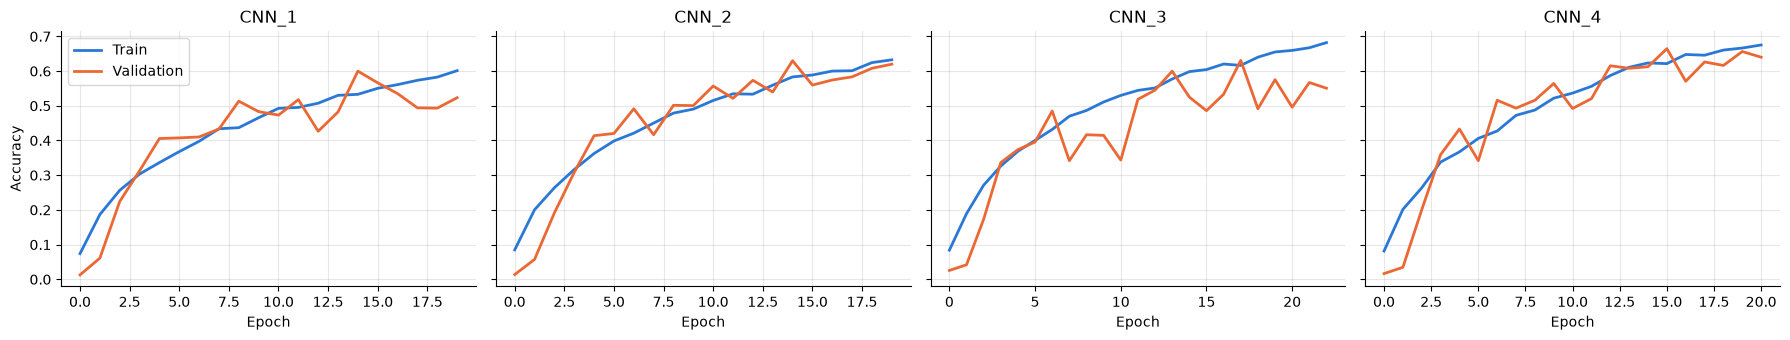

In [10]:
def plot_curves(histories):
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 3.5), sharey=True, squeeze=False)
    for ax, (name, h) in zip(axes[0], histories.items()):
        ax.plot(h['accuracy'], color=TRAIN_C, label='Train')
        ax.plot(h['val_accuracy'], color=VAL_C, label='Validation')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
    axes[0][0].set_ylabel('Accuracy')
    axes[0][0].legend()
    plt.tight_layout()
    plt.show()

plot_curves(histories)